# 경제 분석 및 예측과 데이터 지능 실습 2.2: GARCH·변동성 (KOSPI & 원/달러)

- **데이터:** `datasets/kospi.csv`, `datasets/exchange.csv` 병합 (실행 위치는 프로젝트 루트 또는 `practices/`).
- **목표일:** **2026-03-30** — 마지막 관측(2026-03-27) 이후 **다음 영업일** 수익률·변동성 예측과 **가격/환율 point forecast** (근사 구간 포함).
- **도구:** `arch` (GARCH / GJR / Student-$t$), `statsmodels` (Ljung–Box, ARCH LM).

참고: [arch 문서](https://arch.readthedocs.io/en/stable/univariate/univariate_volatility_modeling.html)

In [59]:
from __future__ import annotations

import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from arch import arch_model
from arch.univariate.base import ARCHModelResult
from IPython.display import display
from scipy import stats
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_style("whitegrid")
plt.rc("figure", figsize=(14, 5))
plt.rc("font", size=11)

TARGET_DATE = pd.Timestamp("2026-03-30")

In [60]:
def resolve_data_dir() -> Path:
    cwd = Path.cwd()
    if (cwd / "datasets" / "kospi.csv").exists():
        return cwd / "datasets"
    if (cwd.parent / "datasets" / "kospi.csv").exists():
        return cwd.parent / "datasets"
    raise FileNotFoundError("Could not find datasets/kospi.csv (run from repo root or practices/).")


DATA = resolve_data_dir()
fx = pd.read_csv(DATA / "exchange.csv", parse_dates=["DATE"])
kp = pd.read_csv(DATA / "kospi.csv", parse_dates=["DATE"])
df = fx.merge(kp, on="DATE", how="inner").sort_values("DATE").set_index("DATE")
df = df.rename(columns={"EXCHANGE": "FX_WON_PER_USD", "CLOSE": "KOSPI_CLOSE"})
print(df.index.min(), "->", df.index.max(), "|", len(df), "trading days")
df.tail()


2020-01-02 00:00:00 -> 2026-03-27 00:00:00 | 1530 trading days


,FX_WON_PER_USD,OPEN,HIGH,LOW,KOSPI_CLOSE,VOLUME,VALUE
DATE,,,,,,,
2026-03-23,1494.9,5580.15,5580.15,5397.94,5405.75,1125619649,27243225200168
2026-03-24,1509.6,5638.20,5643.00,5395.17,5553.92,1170517963,24932387802374
2026-03-25,1498.3,5680.33,5740.97,5630.07,5642.21,763223598,24642071803976
2026-03-26,1495.6,5594.06,5598.37,5448.12,5460.46,925092573,25615327461870
2026-03-27,1506.2,5300.61,5462.51,5220.10,5438.87,900080937,23659342023182


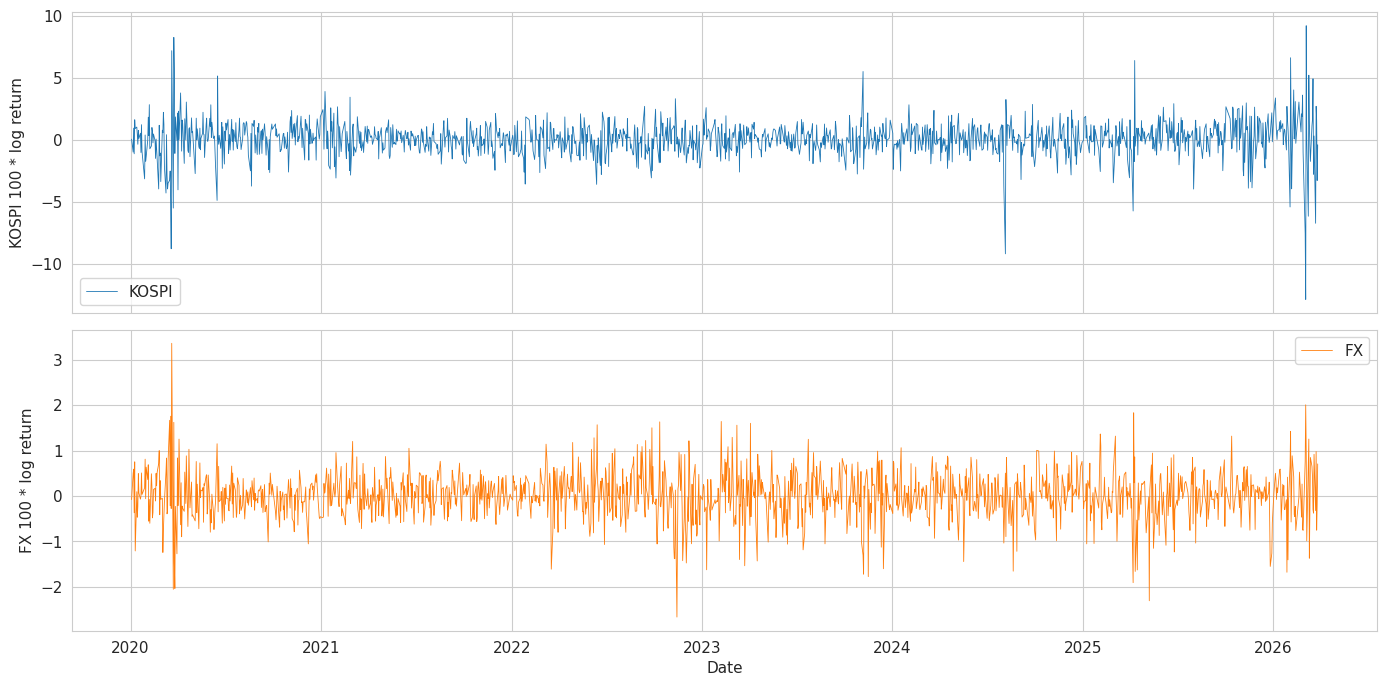

,count,mean,std,min,25%,50%,75%,max
r_kospi,1529.0,0.059939,1.430038,-12.848905,-0.647569,0.112209,0.834092,9.191439
r_fx,1529.0,0.017205,0.519701,-2.662682,-0.270925,0.022595,0.304216,3.360259


In [61]:
# 100 * log difference (~percent scale)
df["r_kospi"] = 100 * np.log(df["KOSPI_CLOSE"] / df["KOSPI_CLOSE"].shift(1))
df["r_fx"] = 100 * np.log(df["FX_WON_PER_USD"] / df["FX_WON_PER_USD"].shift(1))
rets = df[["r_kospi", "r_fx"]].dropna()

fig, axes = plt.subplots(2, 1, sharex=True, figsize=(14, 7))
axes[0].plot(rets.index, rets["r_kospi"], lw=0.6, label="KOSPI")
axes[0].set_ylabel("KOSPI 100 * log return")
axes[0].legend()
axes[1].plot(rets.index, rets["r_fx"], lw=0.6, color="C1", label="FX")
axes[1].set_ylabel("FX 100 * log return")
axes[1].set_xlabel("Date")
axes[1].legend()
plt.tight_layout()
plt.show()

display(rets.describe().T)


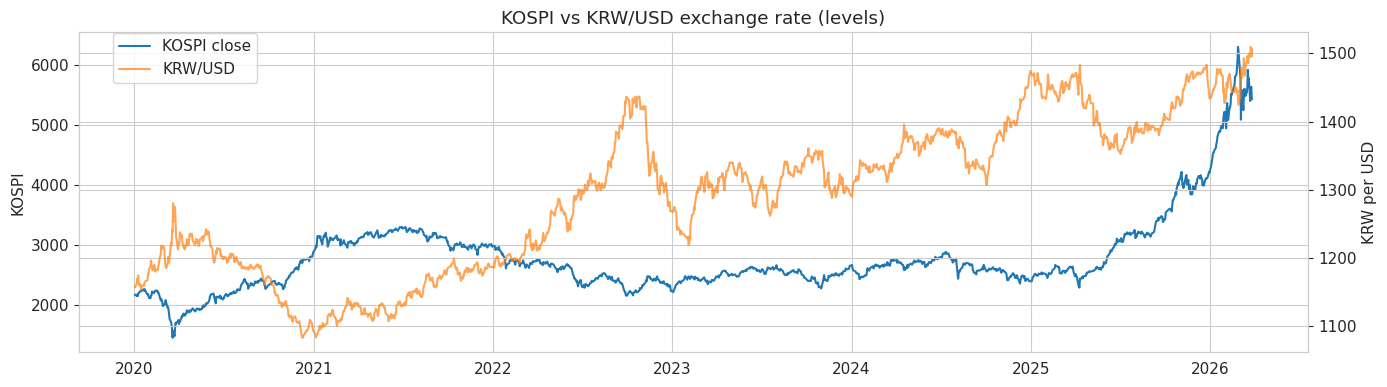

KOSPI-FX return correlation: 0.0155


In [62]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df.index, df["KOSPI_CLOSE"], label="KOSPI close")
ax.set_ylabel("KOSPI")
ax2 = ax.twinx()
ax2.plot(df.index, df["FX_WON_PER_USD"], color="C1", alpha=0.7, label="KRW/USD")
ax2.set_ylabel("KRW per USD")
ax.set_title("KOSPI vs KRW/USD exchange rate (levels)")
fig.legend(loc="upper left", bbox_to_anchor=(0.08, 0.92))
plt.tight_layout()
plt.show()

print("KOSPI-FX return correlation:", round(rets["r_kospi"].corr(rets["r_fx"]), 4))


In [63]:
def trading_days_ahead(last: pd.Timestamp, target: pd.Timestamp) -> int:
    if target <= last:
        return 0
    h = 0
    d = last
    while d < target:
        d = d + pd.offsets.BDay(1)
        h += 1
    return h


last_dt = rets.index.max()
horizon = trading_days_ahead(last_dt, TARGET_DATE)
print(f"Last obs: {last_dt.date()} | Target: {TARGET_DATE.date()} | horizon (business days) = {horizon}")
assert horizon > 0, "Target is on or before last sample date; update CSV or TARGET_DATE."


def extract_persistence(params: pd.Series) -> float | None:
    a = sum(float(params[k]) for k in params.index if str(k).startswith("alpha"))
    b = sum(float(params[k]) for k in params.index if str(k).startswith("beta"))
    g = sum(float(params[k]) for k in params.index if str(k).startswith("gamma"))
    if a == 0 and b == 0:
        return None
    return a + b + g


def garch_half_life(persistence: float) -> float | None:
    if persistence <= 0 or persistence >= 1:
        return None
    return float(np.log(0.5) / np.log(persistence))


def unconditional_var(omega: float, persistence: float) -> float | None:
    if persistence >= 1:
        return None
    return float(omega / (1.0 - persistence))


def metrics_report(name: str, res: ARCHModelResult) -> pd.Series:
    p = res.params
    pers = extract_persistence(p)
    omega = float(p.get("omega", np.nan))
    unc = unconditional_var(omega, pers) if pers is not None else None
    hl = garch_half_life(pers) if pers is not None else None
    return pd.Series(
        {
            "model": name,
            "n_obs": int(res.nobs),
            "loglik": float(res.loglikelihood),
            "aic": float(res.aic),
            "bic": float(res.bic),
            "persistence": np.nan if pers is None else pers,
            "half_life_days": np.nan if hl is None else hl,
            "uncond_var": np.nan if unc is None else unc,
            "uncond_vol_daily": np.nan if unc is None else np.sqrt(unc),
        }
    )


def residual_diagnostics(std_resid: pd.Series, lags=(10, 20)):
    z = std_resid.dropna()
    rows = []
    for lag in lags:
        lb = acorr_ljungbox(z, lags=[lag], model_df=0, return_df=True)
        lb2 = acorr_ljungbox(z**2, lags=[lag], model_df=0, return_df=True)
        rows.append(
            {
                "lag": lag,
                "LB_z": float(lb["lb_stat"].iloc[0]),
                "p_z": float(lb["lb_pvalue"].iloc[0]),
                "LB_z2": float(lb2["lb_stat"].iloc[0]),
                "p_z2": float(lb2["lb_pvalue"].iloc[0]),
            }
        )
    arch_lm, arch_p, _, _ = het_arch(z, nlags=5)
    return pd.DataFrame(rows), float(arch_lm), float(arch_p)


Last obs: 2026-03-27 | Target: 2026-03-30 | horizon (business days) = 1


In [64]:
def fit_compare(y: pd.Series, label: str):
    specs = {
        "GARCH(1,1)-Normal": dict(p=1, q=1, o=0, dist="normal"),
        "GJR(1,1,1)-Normal": dict(p=1, q=1, o=1, dist="normal"),
        "GARCH(1,1)-StudentT": dict(p=1, q=1, o=0, dist="t"),
        "GJR(1,1,1)-StudentT": dict(p=1, q=1, o=1, dist="t"),
    }
    rows, best, best_aic = [], None, np.inf
    for name, kw in specs.items():
        am = arch_model(y, mean="Constant", vol="GARCH", **kw)
        res = am.fit(disp="off", show_warning=False)
        rows.append(metrics_report(name, res))
        if res.aic < best_aic:
            best_aic, best = res.aic, res
    tab = pd.DataFrame(rows).set_index("model")
    print(f"=== {label}: AIC / BIC / log-lik / persistence / unconditional variance ===")
    display(tab.round(4))
    return best, tab


y_k, y_f = rets["r_kospi"], rets["r_fx"]
best_k, tab_k = fit_compare(y_k, "KOSPI")
best_f, tab_f = fit_compare(y_f, "FX")


=== KOSPI: AIC / BIC / log-lik / persistence / unconditional variance ===


,n_obs,loglik,aic,bic,persistence,half_life_days,uncond_var,uncond_vol_daily
model,,,,,,,,
"GARCH(1,1)-Normal",1529,-2464.0014,4936.0028,4957.3323,0.9151,7.8127,1.9926,1.4116
"GJR(1,1,1)-Normal",1529,-2454.9391,4919.8783,4946.5401,0.9962,183.9999,45.4468,6.7414
"GARCH(1,1)-StudentT",1529,-2436.7793,4883.5586,4910.2205,0.9126,7.5783,1.8042,1.3432
"GJR(1,1,1)-StudentT",1529,-2428.9700,4869.9400,4901.9342,0.9865,51.1604,12.9609,3.6001


=== FX: AIC / BIC / log-lik / persistence / unconditional variance ===


,n_obs,loglik,aic,bic,persistence,half_life_days,uncond_var,uncond_vol_daily
model,,,,,,,,
"GARCH(1,1)-Normal",1529,-1084.8210,2177.6421,2198.9716,0.9716,24.0552,0.2778,0.5271
"GJR(1,1,1)-Normal",1529,-1084.7633,2179.5267,2206.1885,0.9696,22.4629,0.2524,0.5024
"GARCH(1,1)-StudentT",1529,-1050.2843,2110.5685,2137.2304,0.9702,22.9412,0.2854,0.5342
"GJR(1,1,1)-StudentT",1529,-1050.0935,2112.1870,2144.1813,0.9649,19.3866,0.2318,0.4814


KOSPI (AIC-min model)
                      Constant Mean - GJR-GARCH Model Results                       
Dep. Variable:                      r_kospi   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                        GJR-GARCH   Log-Likelihood:               -2428.97
Distribution:      Standardized Student's t   AIC:                           4869.94
Method:                  Maximum Likelihood   BIC:                           4901.93
                                              No. Observations:                 1529
Date:                      Sun, Mar 29 2026   Df Residuals:                     1528
Time:                              21:13:55   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
---------------------------------------------------------------

,value
model,AIC-min
n_obs,1529
loglik,-2428.970015
aic,4869.94003
bic,4901.934246
persistence,0.986543
half_life_days,51.160406
uncond_var,12.960851
uncond_vol_daily,3.600118


Ljung-Box (H0: white noise): standardized vs squared residuals


,lag,LB_z,p_z,LB_z2,p_z2
0,10,13.3422,0.2052,10.1711,0.4256
1,20,19.9609,0.4604,30.2311,0.0662


ARCH LM(5): stat=7.0209, p=0.2191 (H0: no remaining ARCH)


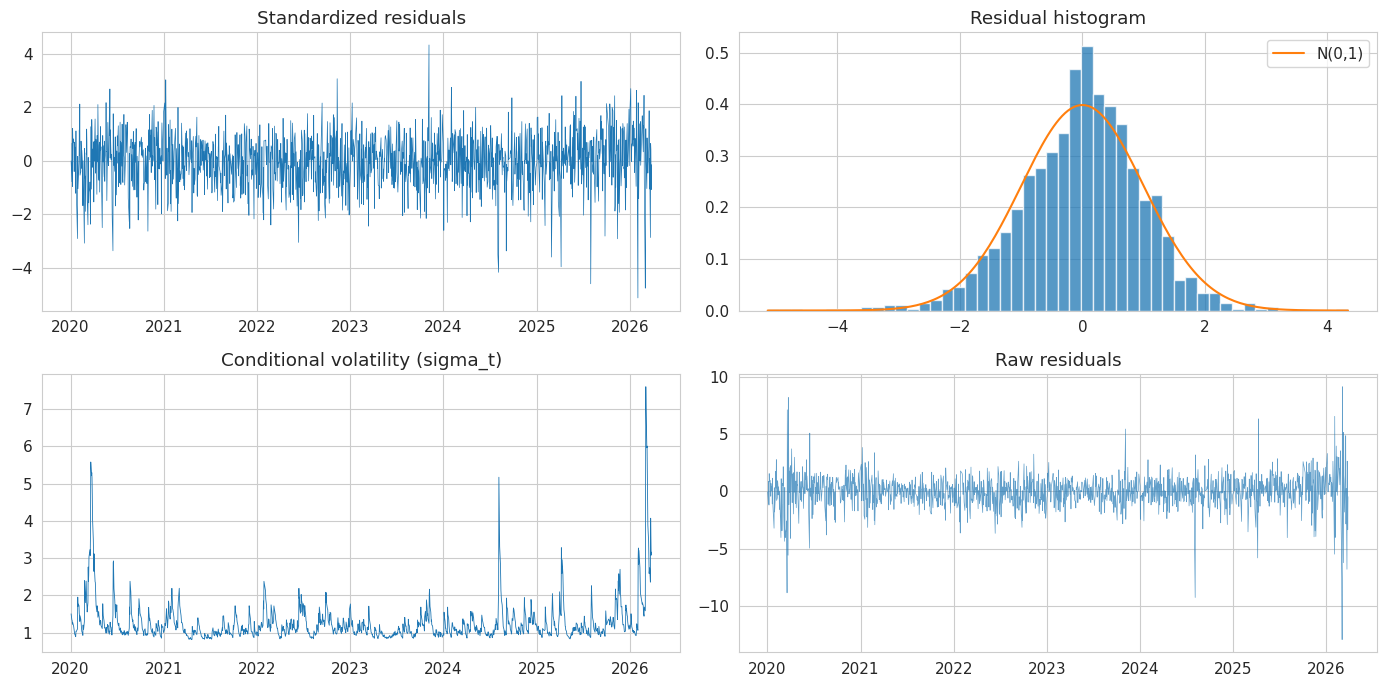

FX (AIC-min model)
                        Constant Mean - GARCH Model Results                         
Dep. Variable:                         r_fx   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:               -1050.28
Distribution:      Standardized Student's t   AIC:                           2110.57
Method:                  Maximum Likelihood   BIC:                           2137.23
                                              No. Observations:                 1529
Date:                      Sun, Mar 29 2026   Df Residuals:                     1528
Time:                              21:13:55   Df Model:                            1
                                 Mean Model                                 
                 coef    std err          t      P>|t|      95.0% Conf. Int.
--------------------------------------------------------------

,value
model,AIC-min
n_obs,1529
loglik,-1050.284267
aic,2110.568534
bic,2137.23038
persistence,0.970238
half_life_days,22.941192
uncond_var,0.285406
uncond_vol_daily,0.534234


Ljung-Box (H0: white noise): standardized vs squared residuals


,lag,LB_z,p_z,LB_z2,p_z2
0,10,22.2322,0.0140,11.5936,0.3132
1,20,31.6036,0.0477,64.1376,0.0000


ARCH LM(5): stat=7.9494, p=0.1590 (H0: no remaining ARCH)


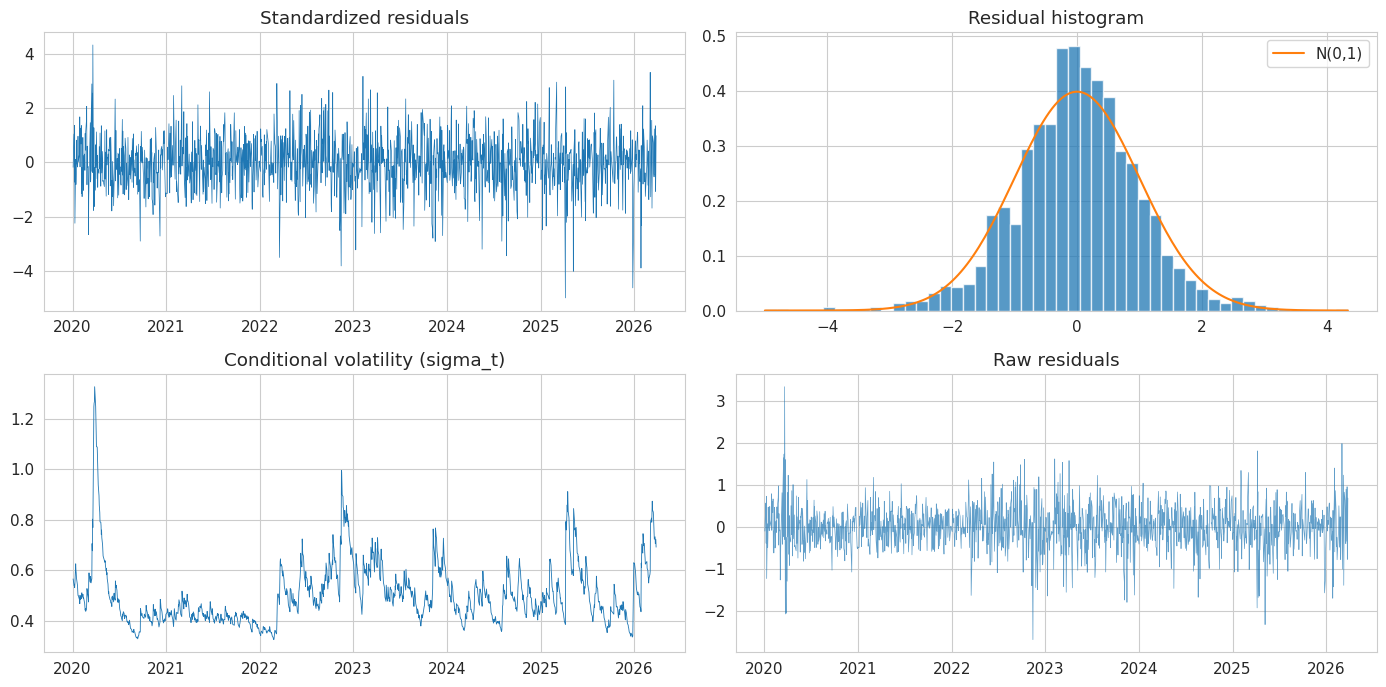

In [65]:
def show_diagnostics(res: ARCHModelResult, y: pd.Series, title: str):
    print("=" * 60, "\n", title, "\n", "=" * 60, sep="")
    print(res.summary())
    display(metrics_report("AIC-min", res).to_frame("value").round(6))

    z = pd.Series(res.std_resid, index=res.resid.index)
    df_lb, arch_lm, arch_p = residual_diagnostics(z)
    print("Ljung-Box (H0: white noise): standardized vs squared residuals")
    display(df_lb.round(4))
    print(f"ARCH LM(5): stat={arch_lm:.4f}, p={arch_p:.4f} (H0: no remaining ARCH)")

    fig, axes = plt.subplots(2, 2, figsize=(14, 7))
    axes[0, 0].plot(z.index, z, lw=0.5)
    axes[0, 0].set_title("Standardized residuals")
    axes[0, 1].hist(z.dropna(), bins=50, density=True, alpha=0.75)
    xs = np.linspace(z.min(), z.max(), 200)
    axes[0, 1].plot(xs, stats.norm.pdf(xs), color="C1", label="N(0,1)")
    axes[0, 1].legend()
    axes[0, 1].set_title("Residual histogram")
    axes[1, 0].plot(res.conditional_volatility.index, res.conditional_volatility, lw=0.6)
    axes[1, 0].set_title("Conditional volatility (sigma_t)")
    axes[1, 1].plot(y.index, res.resid, lw=0.5, alpha=0.7)
    axes[1, 1].set_title("Raw residuals")
    plt.tight_layout()
    plt.show()


show_diagnostics(best_k, y_k, "KOSPI (AIC-min model)")
show_diagnostics(best_f, y_f, "FX (AIC-min model)")


In [66]:
def forecast_report(res: ARCHModelResult, last_price: float, horizon: int, label: str):
    fc = res.forecast(horizon=horizon, reindex=False)
    mu_row = fc.mean.iloc[-1].values.astype(float)
    var_row = fc.variance.iloc[-1].values.astype(float)
    mu1, v1 = float(mu_row[0]), float(var_row[0])
    cum_log = float(np.sum(mu_row / 100.0))
    p_hat = last_price * np.exp(cum_log)
    cum_var_approx = float(np.sum(var_row))
    z95 = 1.96
    lo_r = float(np.sum(mu_row) - z95 * np.sqrt(cum_var_approx))
    hi_r = float(np.sum(mu_row) + z95 * np.sqrt(cum_var_approx))
    p_lo = last_price * np.exp(lo_r / 100.0)
    p_hi = last_price * np.exp(hi_r / 100.0)

    print(f"\n>>> {label} | target {TARGET_DATE.date()} (h={horizon} business days)")
    print(f"    Last level: {last_price:,.2f}")
    print(f"    1-step E[100*log r]: {mu1:.6f} | conditional sigma: {np.sqrt(v1):.6f}")
    print(f"    Sum E[100*log r] (approx): {np.sum(mu_row):.6f}")
    print(f"    Point forecast level: {p_hat:,.2f}")
    print(f"    Approx 95% level band (normal, cumulative): [{p_lo:,.2f}, {p_hi:,.2f}]")


last_k = float(df.loc[last_dt, "KOSPI_CLOSE"])
last_f = float(df.loc[last_dt, "FX_WON_PER_USD"])
forecast_report(best_k, last_k, horizon, "KOSPI close")
forecast_report(best_f, last_f, horizon, "KRW/USD")



>>> KOSPI close | target 2026-03-30 (h=1 business days)
    Last level: 5,438.87
    1-step E[100*log r]: 0.069693 | conditional sigma: 2.719748
    Sum E[100*log r] (approx): 0.069693
    Point forecast level: 5,442.66
    Approx 95% level band (normal, cumulative): [5,160.13, 5,740.67]

>>> KRW/USD | target 2026-03-30 (h=1 business days)
    Last level: 1,506.20
    1-step E[100*log r]: 0.022805 | conditional sigma: 0.686696
    Sum E[100*log r] (approx): 0.022805
    Point forecast level: 1,506.54
    Approx 95% level band (normal, cumulative): [1,486.40, 1,526.96]


## 해석·주의

- **AIC/BIC/LogLik:** 같은 표본에서의 **상대** 비교. 낮은 AIC가 복잡도 페널티를 고려해 선호되는 경우가 많음.
- **Persistence** ($\sum\alpha+\sum\beta+\cdots$): 1에 가까우면 충격이 오래 남음; 1 이상이면 무조건분산 비안정.
- **Half-life:** 분산 충격이 절반으로 줄어드는 데 걸리는 **근사** 일수 (GARCH(1,1) 직관).
- **Ljung-Box / ARCH LM:** 표준화 잔차·제곱에 자기상관이 남았는지. $p$가 작으면 모형·분포 확장 검토.
- **가격 구간:** 누적 수익에 대한 **정규·독립 근사**라 강한 가정; 보고용으론 시뮬레이션 구간이 더 안전.


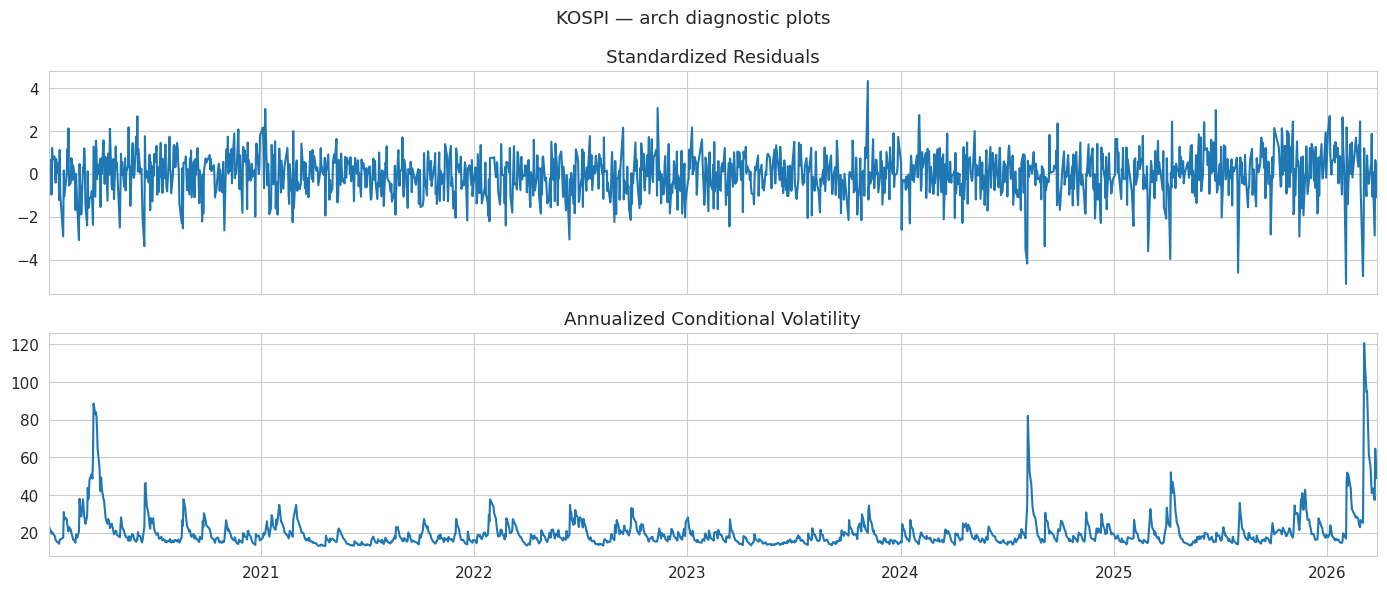

In [67]:
fig1 = best_k.plot(annualize="D")
fig1.set_size_inches(14, 6)
plt.suptitle("KOSPI — arch diagnostic plots")
plt.tight_layout()
plt.show()


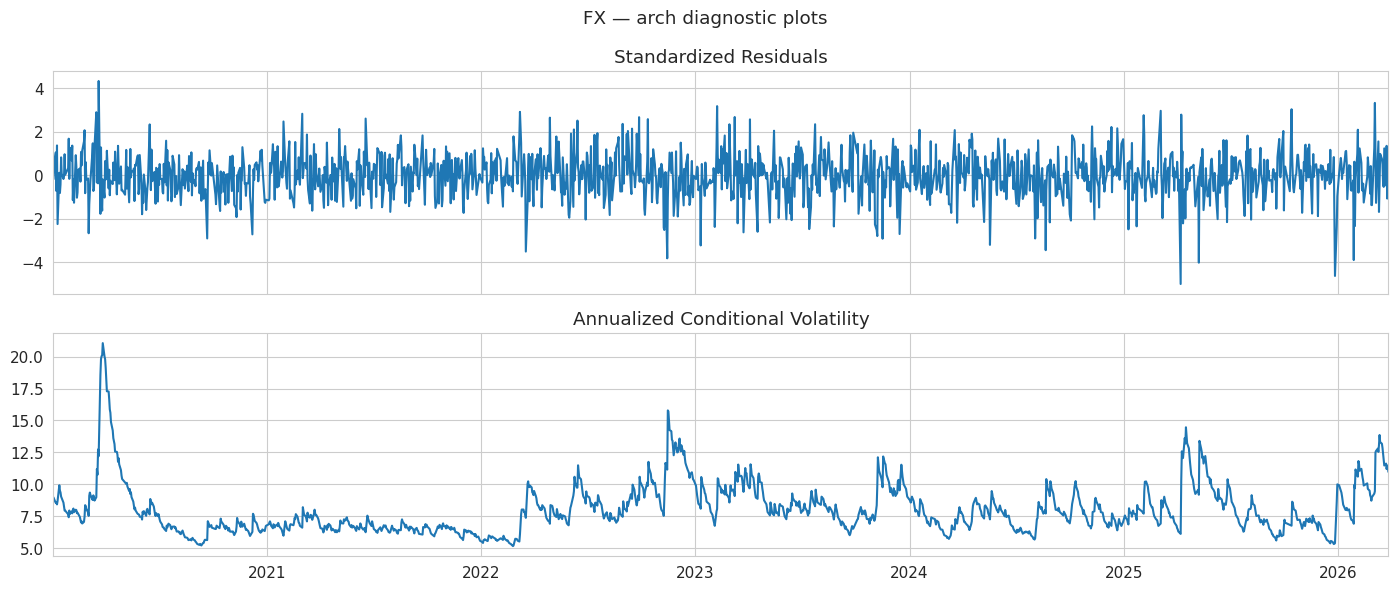

In [68]:
fig2 = best_f.plot(annualize="D")
fig2.set_size_inches(14, 6)
plt.suptitle("FX — arch diagnostic plots")
plt.tight_layout()
plt.show()


## 추가 실험 (컴팩트)

아래 셀은 **KOSPI·FX 각각 3×3 패널**을 그려 **PNG 두 장**으로 저장합니다. 수업에서는 두 파일을 나란히 띄우면 됩니다.

- 중복된 다일차(h=1/h=2) 시뮬 요약은 제거하고, **다음 영업일(h=1) 시뮬**만 표시합니다.


In [69]:
# --- Compact 3x3 panels: save KOSPI and FX as separate PNG files (display side-by-side in class) ---
from dataclasses import dataclass

def _figure_dir() -> Path:
    cwd = Path.cwd()
    if (cwd / "datasets").is_dir():
        d = cwd / "practices" / "figures"
    else:
        d = cwd / "figures"
    d.mkdir(parents=True, exist_ok=True)
    return d


FIG_DIR = _figure_dir()


@dataclass
class VolSpec:
    name: str
    kwargs: dict


def build_model(y: pd.Series, spec: VolSpec):
    kw = {"mean": "Constant", **spec.kwargs}
    if "vol" not in kw:
        kw["vol"] = "GARCH"
    return arch_model(y, **kw)


ZOO = [
    VolSpec("ARCH", {"vol": "ARCH", "p": 1, "q": 0}),
    VolSpec("GARCH", {"p": 1, "q": 1, "o": 0}),
    VolSpec("GJR", {"p": 1, "q": 1, "o": 1}),
    VolSpec("EGARCH", {"vol": "EGARCH", "p": 1, "o": 1, "q": 1}),
]
ROLL_SPECS = [s for s in ZOO if s.name in ("GARCH", "GJR", "EGARCH")]


def qlike(s2: np.ndarray, r2: np.ndarray) -> float:
    s2 = np.clip(s2, 1e-12, None)
    return float(np.mean(np.log(s2) + r2 / s2))


def rolling_one(
    y: pd.Series, spec: VolSpec, window: int, step: int
) -> tuple[list, np.ndarray, np.ndarray]:
    ts, s2s, r2s = [], [], []
    for t in range(window, len(y), step):
        train = y.iloc[t - window : t]
        try:
            res = build_model(train, spec).fit(disp="off", show_warning=False)
            fc = res.forecast(horizon=1, reindex=False)
            s2 = float(fc.variance.iloc[-1, 0])
            ts.append(y.index[t])
            s2s.append(s2)
            r2s.append(float(y.iloc[t]) ** 2)
        except Exception:
            continue
    return ts, np.array(s2s), np.array(r2s)


def vol_panel_3x3(
    y: pd.Series,
    level: pd.Series,
    asset: str,
    png_name: str,
    roll_window: int = 252,
    roll_step: int = 5,
    n_sim: int = 4000,
) -> Path:
    """Nine panels: returns, level, AIC zoo; GARCH vol & residuals & split persistence;
    rolling GARCH; 1-step sim levels (GARCH); rolling QLIKE bars (GARCH/GJR/EGARCH)."""
    fig, ax = plt.subplots(3, 3, figsize=(11, 9), layout="constrained")
    fig.suptitle(f"{asset}: volatility overview (compact)", fontsize=12, fontweight="bold")

    # --- Row 0: returns, level, AIC ---
    ax[0, 0].plot(y.index, y.values, lw=0.5)
    ax[0, 0].set_title("100 * log return")
    ax[0, 0].tick_params(axis="x", rotation=25, labelsize=7)

    ax[0, 1].plot(level.index, level.values, lw=0.5, color="C1")
    ax[0, 1].set_title("Level (close / FX)")
    ax[0, 1].tick_params(axis="x", rotation=25, labelsize=7)

    aics, names = [], []
    fitted = {}
    for spec in ZOO:
        try:
            res = build_model(y, spec).fit(disp="off", show_warning=False)
            fitted[spec.name] = res
            aics.append(res.aic)
            names.append(spec.name)
        except Exception:
            continue
    ax[0, 2].bar(names, aics, color=["C0", "C1", "C2", "C3"][: len(names)])
    ax[0, 2].set_title("AIC (lower better)")
    ax[0, 2].tick_params(axis="x", rotation=20, labelsize=8)

    # --- Row 1: GARCH conditional vol, std resid hist, split persistence (GARCH only) ---
    res_g = build_model(y, ZOO[1]).fit(disp="off", show_warning=False)
    cv = res_g.conditional_volatility
    ax[1, 0].plot(cv.index, cv.values, lw=0.5, color="C2")
    ax[1, 0].set_title("GARCH(1,1) conditional sigma")
    ax[1, 0].tick_params(axis="x", rotation=25, labelsize=7)

    z = pd.Series(res_g.std_resid, index=res_g.resid.index).dropna()
    ax[1, 1].hist(z, bins=40, density=True, alpha=0.85, color="C0")
    ax[1, 1].set_title("Std. residuals (GARCH)")

    half = len(y) // 2
    pers = []
    for sl in [slice(0, half), slice(half, None)]:
        try:
            r_ = build_model(y.iloc[sl], ZOO[1]).fit(disp="off", show_warning=False)
            p = r_.params
            a = sum(float(p[k]) for k in p.index if str(k).startswith("alpha"))
            b = sum(float(p[k]) for k in p.index if str(k).startswith("beta"))
            g = sum(float(p[k]) for k in p.index if str(k).startswith("gamma"))
            pers.append(a + b + g)
        except Exception:
            pers.append(float("nan"))
    ax[1, 2].bar(["1st half", "2nd half"], pers, color=["C0", "C1"])
    ax[1, 2].set_title("GARCH persistence by split")
    ax[1, 2].set_ylim(0, 1.05)

    # --- Row 2: rolling GARCH sigma vs |r|; 1-step sim levels (GARCH); QLIKE compare ---
    ts_r, s2r, _ = rolling_one(y, ZOO[1], roll_window, roll_step)
    if len(s2r) > 0:
        ax[2, 0].plot(ts_r, np.sqrt(s2r), lw=0.8, label="forecast sigma")
        abs_r = np.abs(y.reindex(ts_r).values)
        ax[2, 0].plot(ts_r, abs_r, lw=0.6, alpha=0.75, label="|r|")
        ax[2, 0].set_title(f"Rolling GARCH (w={roll_window})")
        ax[2, 0].legend(fontsize=6)
        ax[2, 0].tick_params(axis="x", rotation=25, labelsize=7)
    else:
        ax[2, 0].set_visible(False)

    last_lv = float(level.iloc[-1])
    sim = res_g.forecast(horizon=1, method="simulation", simulations=n_sim, reindex=False)
    vals = sim.simulations.values[0][:, 0]
    levels_sim = last_lv * np.exp(vals / 100.0)
    ax[2, 1].hist(levels_sim, bins=45, density=True, alpha=0.85, color="C3")
    ax[2, 1].axvline(float(np.mean(levels_sim)), color="k", ls="--", lw=1)
    ax[2, 1].set_title("Sim. next-day level (GARCH, h=1)")

    qls, ql_names = [], []
    for spec in ROLL_SPECS:
        _, s2, r2 = rolling_one(y, spec, roll_window, roll_step)
        if len(s2) == 0:
            continue
        q = qlike(s2, r2)
        if np.isfinite(q) and abs(q) < 1e3:
            qls.append(q)
            ql_names.append(spec.name)
    if qls:
        ax[2, 2].barh(ql_names, qls, color="C2")
        ax[2, 2].set_title("Rolling QLIKE (lower better)")
        ax[2, 2].tick_params(labelsize=8)
    else:
        ax[2, 2].set_visible(False)

    out = FIG_DIR / png_name
    fig.savefig(out, dpi=160, bbox_inches="tight")
    plt.close(fig)
    return out


p_k = vol_panel_3x3(y_k, df["KOSPI_CLOSE"], "KOSPI", "kospi_vol_panel.png")
p_f = vol_panel_3x3(y_f, df["FX_WON_PER_USD"], "FX (KRW/USD)", "fx_vol_panel.png")
print("Saved:", p_k.resolve())
print("Saved:", p_f.resolve())


Saved: /home/minkeymouse/projects/snu-forecasting-lecture-TA/practices/figures/kospi_vol_panel.png
Saved: /home/minkeymouse/projects/snu-forecasting-lecture-TA/practices/figures/fx_vol_panel.png
